In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
df = pd.read_csv('Superstore.csv', encoding='windows-1252')
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

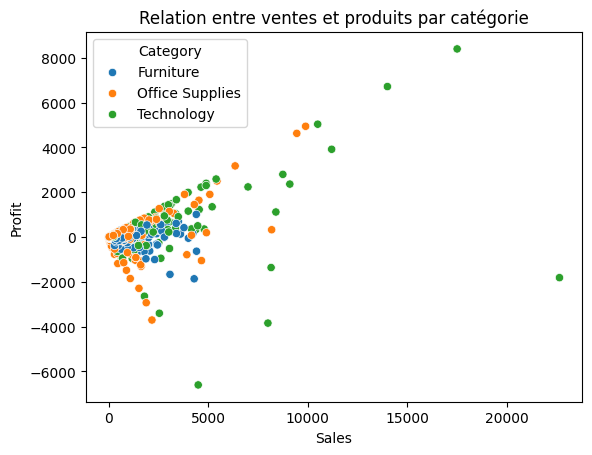

In [7]:
sns.scatterplot(data=df, x='Sales', y='Profit', hue='Category')
plt.title("Relation entre ventes et produits par catégorie")
plt.show()

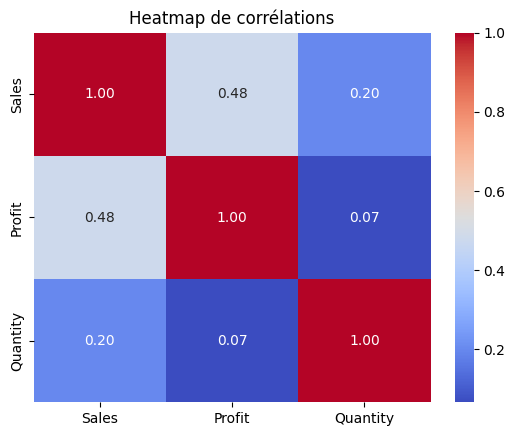

In [8]:
colonnes_num = ['Sales', 'Profit', 'Quantity']
correlations = df[colonnes_num].corr()
sns.heatmap(correlations, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Heatmap de corrélations")
plt.show()

In [10]:
moyenne_par_region = df.groupby('Region')['Profit'].mean().sort_values(ascending=False)
print("Profit moyen par région :")
print(moyenne_par_region)

Profit moyen par région :
Region
West       33.849032
East       32.135808
South      28.857673
Central    17.092709
Name: Profit, dtype: float64


<function matplotlib.pyplot.show(close=None, block=None)>

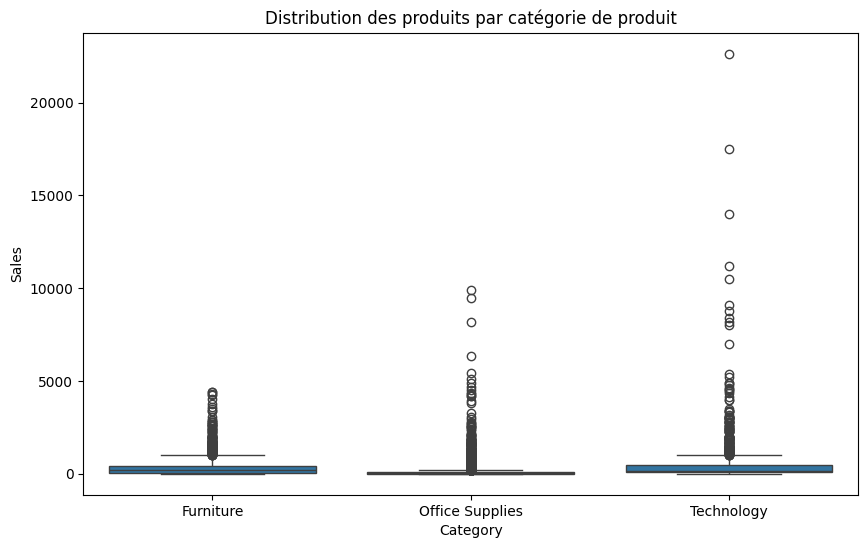

In [12]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Category', y='Sales')
plt.title("Distribution des produits par catégorie de produit")
plt.show



Repartition des commandes
Category  Furniture  Office Supplies  Technology
Region                                          
Central         481             1422         420
East            601             1712         535
South           332              995         293
West            707             1897         599


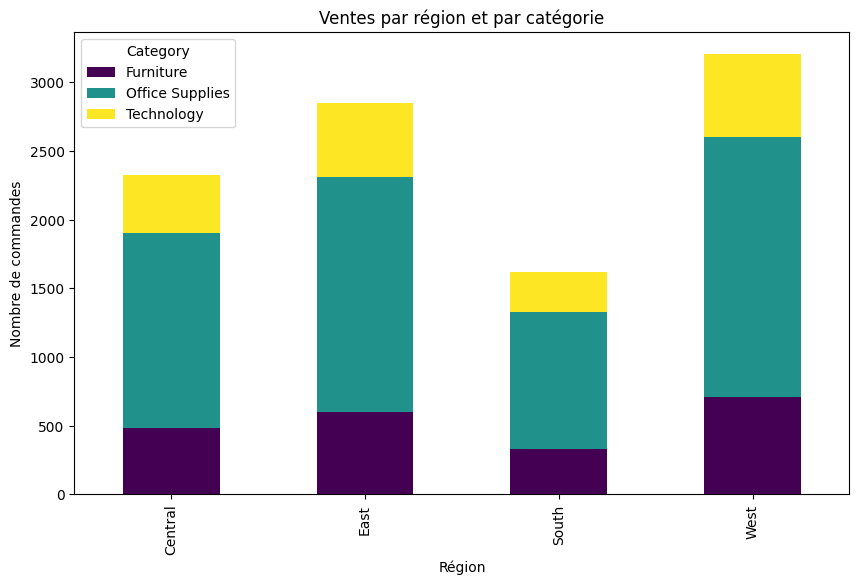

In [13]:
tableau_croise = pd.crosstab(df['Region'], df['Category'])
print('Repartition des commandes')
print(tableau_croise)

tableau_croise.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='viridis')
plt.title('Ventes par région et par catégorie')
plt.xlabel('Région')
plt.ylabel('Nombre de commandes')
plt.show()

'analyse des données révèle que les fournitures de bureau dominent largement les volumes de commandes globales. Sur le plan géographique, la région Ouest s'impose comme le véritable moteur de l'entreprise sur l'ensemble du catalogue, tandis que la région Sud accuse un retard d'activité important. Pour optimiser la rentabilité, la priorité immédiate est de plafonner strictement les remises accordées, car la matrice de corrélation montre qu'elles détruisent directement la marge commerciale. Il est également nécessaire d'auditer la catégorie du mobilier, qui génère de lourdes pertes financières malgré des volumes de ventes corrects. Enfin, d'un point de vue stratégique, il conviendrait de lancer des campagnes d'acquisition pour redynamiser le Sud, tout en se concentrant sur la maximisation de la rentabilité de l'excellente base client déjà établie à l'Ouest.